# Privacy and Governance Analysis

This notebook has the intention to analyse the risks regarding privacy on the start-ups credit aplications dataset. Meaning that it evaluates the privacy, regulatory and governance implications of the findings indentified in the previous project analyses.  

NovaCred is a fintech company using machine learning models to support credit approval decisions. Because credit scoring directly affects individuals' access to financial services, such systems involve sensitive personal data and significant regulatory obligations.

This notebook examines whether the dataset and analytical pipeline meet key requirements related to:
- personal data protection  
- data governance  
- regulatory compliance  
- responsible AI practices


### Relationship with Previous Analyses

This notebook builds directly on the findings of Notebook 02 (Bias Analysis) and addresses the privacy and governance obligations that those findings trigger. Credit scoring is classified as a high-risk AI system under the EU AI Act (Annex III, No. 5b), which means it is subject to both GDPR and AI Act requirements simultaneously.

Examples include:
- duplicate SSNs linked to multiple individuals  
- demographic attributes used in bias analysis  
- proxy variables that may reveal protected characteristics  
- missing governance metadata such as consent timestamps or audit logs

This analysis was performed on the dataset that was already cleaned and prepared by the data team. It will be possile to focus on privacy and governance, preventing techinical mistakes related to data quality.

## 0. Setup and Load Data

### Sections
1. Setup & Load Data
2. PII Classification 
3. Privacy Risk Mitigation
4. Pseudonymization
5. GDPR Mapping 
6. Governance Recommendations


---

### Regulatory Framework

| Regulation | Relevance |
|---|---|
| **GDPR** (Regulation (EU) 2016/679) | Governs all processing of personal data — lawful basis, data minimisation, storage limitation, rights of data subjects |
| **EU AI Act** (Regulation (EU) 2024/1689) | Credit scoring = high-risk AI (Annex III) — requires risk management, data governance, transparency, human oversight |
| **EDPB Guidelines 04/2022** | Guidance on data minimisation and purpose limitation in automated decision-making |
| **EDPB Opinion 05/2019** | Interplay between the AI Act and GDPR for high-risk AI systems |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import hashlib

df = pd.read_csv('clean_dataset_view.csv')

In [2]:
df.columns
columns_table = df.columns.to_frame(index=False, name='Columns')
columns_table

,Columns
0,_id
1,spending_behavior
2,processing_timestamp
3,full_name
4,email
5,ssn
6,ip_address
7,gender
8,date_of_birth
9,zip_code


## 1. Identification of Personal Data & Classification

The first step in the privacy and governance assessment is to identify which attributes in the dataset cnstitute personal data. 

Under **GDPR Art. 4(1)**, personal data refers to information that allows the identification of an individual, either directly (e.g. name or SSN) or indirectly through the combination of multiple attrributes. For that reason, it should be treated with special security and privacy measures. In this dataset, several potential fields were identified as Personally Identifiable Information (PII). This problem was formally described by **Sweeney (2002)** in the context of re-identification risk and is referenced in **EDPB Guideline 05/2014** on anonymisation techniques.

Based on this framework, we classify dataset attributes according to their potential identifiability risk.

After analysing the columns of the dataset, it is possible to conclude that the following columns are considered personal data. We classify each field by PII type and risk level.
- **Direct identifiers** are attributes that can uniquely identify an individual on their own, such as name, email or SSN.
- **Quasi-identifiers** do not identify a person individually but may allow identification when combined with other attributes, such as date of birth, ZIP code or gender.
- **Technical identifier** contains information that might identify an individual or its devices.
- **Non-personal / Derived attributes** are variables representing system outputs or aggregated results that do not direcrly identify individuals.

| Category | Definition | Examples in Dataset |
|--------|-------------|--------------------|
| **Direct Identifier** | Uniquely identifies a person on its own | full_name, ssn, email |
| **Quasi-Identifier (QI)** | Combination with other attributes may enable identification | date_of_birth, zip_code, gender |
| **Technical Identifier** | Identifies a device or interaction | ip_address |
| **Non-Personal / Derived** | Represents system outputs rather than personal identity | loan_approved, interest_rate |

Although the attributes such as Zip code are not considered sensitive categories under GDPR Art.9, they may act as proxy variables for protected characteristics such as race or socio economic status.
When such attributes are used in automated decision-making systems,they may contribute to indirect discrimination, which was explored in the bias analysis performed in Notebook 02.

This highlights the importance of assessing both privacy risk and algorithmic fairness risks in the governance framework. 

In [3]:
pii_classification = [
    {
        'Column':        '_id',
        'PII Category':  'Direct Identifier',
        'Risk' :        '🔴 High',
        'Justification': 'Primary key linking directly to the record; enables re-identification when combined with other fields.',
        'Recommended Technique': 'Pseudonymisation.',
        'Bias NB Link':  '—'
    },
    {
        'Column':        'full_name',
        'PII Category':  'Direct Identifier',
        'Risk' :        '🔴 High',
        'Justification': 'Direct identifier of the applicant; duplicate name–SSN findings increase re-identification risk.',
        'Recommended Technique': 'Pseudonymisation via hash (HMAC-SHA256 + salt)',
        'Bias NB Link':  'Duplicate SSN / name mismatch flagged'
    },
    {
        'Column':        'ssn',
        'PII Category':  'Direct Identifier (Sensitive)',   
            'Risk' :        '🔴 High',
        'Justification': 'Highly sensitive national identifier; duplicate values indicate integrity and breach risk.',
        'Recommended Technique': 'Tokenisation.',
        'Bias NB Link':  'Data quality NB: duplicate SSN finding'
    },
    {
        'Column':        'date_of_birth',
        'PII Category':  ' Quasi-Identifier (High Risk)',
        'Risk' :        '🟠 High',
        'Justification': 'Used only to derive age groups; storing the full birth date exceeds data minimisation needs.',
        'Recommended Technique': 'Generalisation',
        'Bias NB Link':  'Section 3 — Age-Based Discrimination; Section 5 — Interaction Effects'
    },
    {
        'Column':        'gender',
        'PII Category':  'Quasi-Identifier (Protected Attribute)',
        'Risk' :        '🟠 High',
        'Justification': 'Protected attribute used for fairness auditing; disparate impact detected (DI = 0.77).',
        'Recommended Technique': 'Governance Control',
        'Bias NB Link':  'Section 2 — Gender Disparate Impact (DI = 0.77)'
    },
    {
        'Column':        'zip_code',
        'PII Category':  'Quasi-Identifier (Proxy Risk)',
         'Risk' :        '🟠 High'  ,
        'Justification': 'Strong demographic proxy; high correlation with gender indicates indirect bias risk.',
        'Recommended Technique': 'Geographic generalisation',
        'Bias NB Link':  'Section 4 — Proxy Variable Analysis (corr = −0.805)'
    },
    {
        'Column':        'annual_income',
        'PII Category':  'Quasi-Identifier (Moderate Risk)',
            'Risk' :        '🟡 Medium'     ,
        'Justification': 'Legitimate credit feature but moderately correlated with age.',
        'Recommended Technique': 'Differential privacy',
        'Bias NB Link':  'Section 4 — Proxy Variable Analysis (corr_age = 0.394)'
    },
    {
        'Column':        'credit_history_months',
        'PII Category':  'Quasi-Identifier (Age Proxy)',
            'Risk' :        '🟡 Medium'     ,
        'Justification': 'Strongest age proxy in dataset and key driver of disadvantage for younger applicants.',
        'Recommended Technique': 'Generalisation',
        'Bias NB Link':  'Section 4 — Primary age proxy (corr = 0.649)'
    },
    {
        'Column':        'savings_balance',
        'PII Category':  'Quasi-Identifier (Low-Medium Risk)',
            'Risk' :        '🟡 Medium'     ,
        'Justification': 'Financial feature with mild age correlation; moderate proxy risk.',
        'Recommended Technique': 'Generalisation',
        'Bias NB Link':  'Section 4 — Borderline proxy (corr_age = 0.286)'
    },
    {
        'Column':        'debt_to_income',
        'PII Category':  'Quasi-Identifier (Low Risk)',
            'Risk' :        '🟢 Low'     ,
        'Justification': 'Low proxy correlations; standard indicator of creditworthiness.',
        'Recommended Technique': 'None',
        'Bias NB Link':  'Notebook 01 — negative value truncation'
    },
    {
        'Column':        'spending_category',
        'PII Category':  'Quasi-Identifier (Behavioural)',
            'Risk' :        '🟠 High'     ,
        'Justification': 'Behavioural profiling feature and strongest predictor of approval outcome.',
        'Recommended Technique': 'k-anonymity',
        'Bias NB Link':  'Section 4 — Strongest outcome predictor'
    },
    {
        'Column':        'spending_amount',
        'PII Category':  'Quasi-Identifier (Negligible Risk)',
            'Risk' :        '🟢 Low'     ,
        'Justification': 'No predictive value or demographic correlation; unnecessary for modelling.',
        'Recommended Technique': 'Deletion.',
        'Bias NB Link':  'Section 4 — No predictive value'
    },
    {
        'Column':        'loan_approved',
        'PII Category':  'Quasi-Identifier (Decision Output)',
                'Risk' :        '🟡 Medium'     ,
        'Justification': 'Automated decision outcome requiring auditability and explainability.',
        'Recommended Technique': 'Audit Logging',
        'Bias NB Link':  'Sections 2–5 — Bias metrics'
    },
    {
        'Column':        'processing_timestamp',
        'PII Category':  'Quasi-Identifier (Metadata)',
            'Risk' :        '🟢 Low'     ,
        'Justification': 'Links the record to a point in time and enables retention control.',
        'Recommended Technique': 'Retention Control',
        'Bias NB Link':  '—'
    },
]

pii_df = pd.DataFrame(pii_classification)


display(pii_df.set_index('Column')[['PII Category','Risk','Recommended Technique','Bias NB Link']])

,PII Category,Risk,Recommended Technique,Bias NB Link
Column,,,,
_id,Direct Identifier,🔴 High,Pseudonymisation.,—
full_name,Direct Identifier,🔴 High,Pseudonymisation via hash (HMAC-SHA256 + salt),Duplicate SSN / name mismatch flagged
ssn,Direct Identifier (Sensitive),🔴 High,Tokenisation.,Data quality NB: duplicate SSN finding
date_of_birth,Quasi-Identifier (High Risk),🟠 High,Generalisation,Section 3 — Age-Based Discrimination; Section ...
gender,Quasi-Identifier (Protected Attribute),🟠 High,Governance Control,Section 2 — Gender Disparate Impact (DI = 0.77)
zip_code,Quasi-Identifier (Proxy Risk),🟠 High,Geographic generalisation,Section 4 — Proxy Variable Analysis (corr = −0...
annual_income,Quasi-Identifier (Moderate Risk),🟡 Medium,Differential privacy,Section 4 — Proxy Variable Analysis (corr_age ...
credit_history_months,Quasi-Identifier (Age Proxy),🟡 Medium,Generalisation,Section 4 — Primary age proxy (corr = 0.649)
savings_balance,Quasi-Identifier (Low-Medium Risk),🟡 Medium,Generalisation,Section 4 — Borderline proxy (corr_age = 0.286)


The recommended techniques refer to standard privacy-preserving methods such as pseudonymisation, tokenisation, generalisation, and differential privacy, which are widely recommended in GDPR-compliant data governance frameworks.

#### Legal Basis Summary
Based on the legal and conceptual framework described above, each dataset attribute was evaluated according to its identifiability risk and potential impact on privacy and algorithmic fairness. Direct identifiers such as full_name and ssn fall clearly within the definition of personal data under GDPR Art. 4(1). Quasi-identifiers including date_of_birth, zip_code, and financial attributes may not identify individuals alone but can enable re-identification when combined with other variables. Additionally, behavioural and decision-related attributes (e.g., spending_category and loan_approved) are relevant for profiling and automated decision-making considerations under GDPR Art. 4(4) and Art. 22.


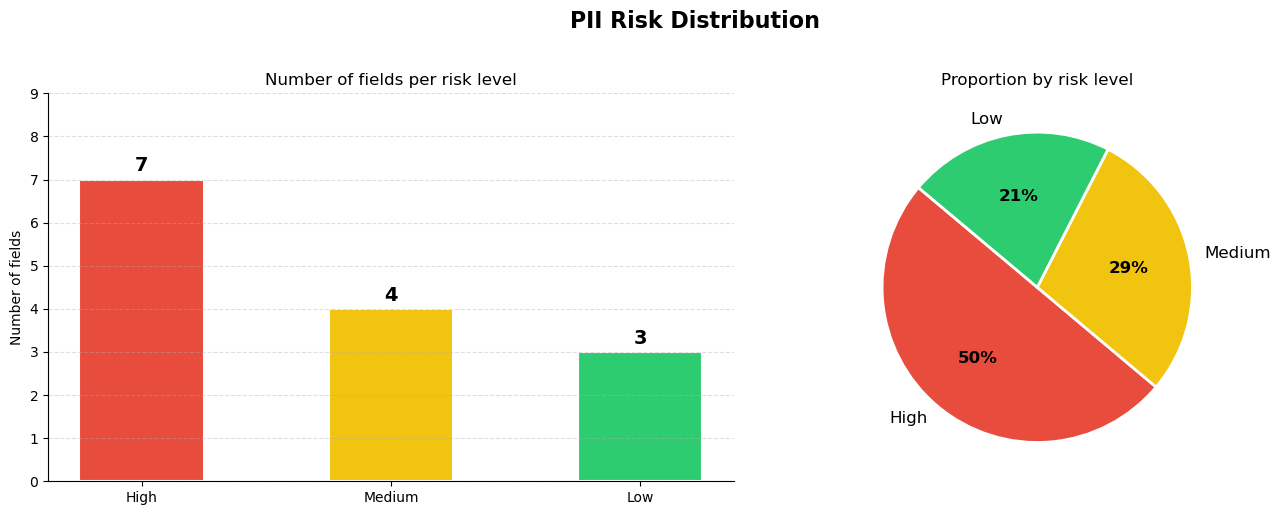

Total PII fields: 14
  High: 7 fields (50%)
  Medium: 4 fields (29%)
  Low: 3 fields (21%)


In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Risk level counts ─────────────────────────────────────────────────────────
risk_counts = pii_df['Risk'].value_counts()

# ── Map to clean labels and colours ──────────────────────────────────────────
grouped = {'High': 0, 'Medium': 0, 'Low': 0}
colors  = {'High': '#e74c3c', 'Medium': '#f1c40f', 'Low': '#2ecc71'}

for risk, count in risk_counts.items():
    if 'High' in risk:
        grouped['High'] += count
    elif 'Medium' in risk:
        grouped['Medium'] += count
    elif 'Low' in risk:
        grouped['Low'] += count

labels     = list(grouped.keys())
values     = list(grouped.values())
bar_colors = [colors[l] for l in labels]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PII Risk Distribution', fontsize=16, fontweight='bold', y=1.02)

# ── Chart 1: Vertical bar chart ───────────────────────────────────────────────
ax1 = axes[0]
bars = ax1.bar(labels, values, color=bar_colors, width=0.5, edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, values):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
             str(val), ha='center', va='bottom', fontsize=14, fontweight='bold')

ax1.set_title('Number of fields per risk level', fontsize=12)
ax1.set_ylabel('Number of fields')
ax1.set_ylim(0, max(values) + 2)
ax1.spines[['top', 'right']].set_visible(False)
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# ── Chart 2: Pie chart ────────────────────────────────────────────────────────
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    values,
    labels=labels,
    colors=bar_colors,
    autopct='%1.0f%%',
    startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    textprops={'fontsize': 12}
)
for at in autotexts:
    at.set_fontweight('bold')

ax2.set_title('Proportion by risk level', fontsize=12)

plt.tight_layout()
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"Total PII fields: {sum(values)}")
for label, val in grouped.items():
    print(f"  {label}: {val} fields ({val/sum(values)*100:.0f}%)")

## 2. Privacy Risk Mitigation

After identifying personal data attributes in the dataset, the next step is to assess how privacy risks are mitigated within the data processing pipeline. Some privacy-preserving transformations are already implemented during the preprocessing stage of the bias analysis.

First, the attribute `date_of_birth` is not used directly. Instead, it is converted into a derived `age` variable, which is later grouped into age categories for fairness analysis. This reduces the identifiability of individuals while preserving the information required for bias evaluation.

Second, direct identifiers and metadata fields such as `_id`, `processing_timestamp`, and `date_of_birth` are explicitly excluded from the proxy analysis feature set. This prevents analytical procedures from relying on attributes that directly identify individuals.

However, some quasi-identifiers remain in their original form. For example, `zip_code` may act as a demographic proxy and is therefore flagged for potential geographic generalisation in future iterations of the pipeline. Similarly, the variable spending_amount was identified as having negligible predictive value and is recommended for removal under the GDPR data minimisation principle.


In [5]:
privacy_actions = pd.DataFrame({
    "Column": [
        "date_of_birth",
        "_id",
        "processing_timestamp",
        "zip_code",
        "spending_amount"
    ],
    "Action Taken": [
        "Converted to age / age_group",
        "Excluded from analysis",
        "Excluded from analysis",
        "Retained (potential proxy)",
        "Retained but recommended for removal"
    ],
    "Technique": [
        "Generalisation",
        "Attribute exclusion",
        "Attribute exclusion",
        "Potential geographic generalisation",
        "Data minimisation"
    ]
})

privacy_actions

,Column,Action Taken,Technique
0,date_of_birth,Converted to age / age_group,Generalisation
1,_id,Excluded from analysis,Attribute exclusion
2,processing_timestamp,Excluded from analysis,Attribute exclusion
3,zip_code,Retained (potential proxy),Potential geographic generalisation
4,spending_amount,Retained but recommended for removal,Data minimisation


These mitigation measures ensure that the fairness analysis operates on a privacy-aware representation of the dataset while preserving the attributes necessary to evaluate potential discrimination.


## 3. Pseudonymization

After identifying and classifying the personal data present in the dataset, the next step is to apply technical measures designed to reduce the risk of direct identification of individuals. One of the main techniques recommended by the GDPR for the protection of personal data is pseudonymization, which consists of replacing direct identifiers with artificial representations that do not allow a person to be identified without access to additional information.

In the context of this credit application dataset, pseudonymization is particularly relevant for attributes that constitute direct identifiers, such as name, email address, SSN, or IP address. These fields allow for the immediate identification of an individual and, therefore, represent a high risk in case of unauthorized access or misuse of the data. 

For this project, Pseudonymization is applied to direct identifiers that are not necessary for the analysis of the credit decision process. In this way, the exposure of sensitive data is reduced without compromising the analytical capacity of the dataset.

It is important to note that pseudonymization significantly reduces the risk of direct identification of individuals, but does not completely eliminate this risk. According to the GDPR, pseudonymized data continues to be considered personal data, since re-identification may be possible if there is access to additional information or through combination with other variables in the dataset. For this reason, pseudonymization should be seen as a risk mitigation measure and not as a complete anonymization solution. This distinction between pseudonymization and anonymization is recognized in the GDPR Recital 26.

In [6]:
def pseudonymize(value):
    if pd.isna(value):
        return None
    return hashlib.sha256(str(value).encode()).hexdigest()

pii_columns = ["full_name", "email", "ssn", "ip_address"]

for col in pii_columns:
    df[col + "_pseudo"] = df[col].apply(pseudonymize)

df = df.drop(columns=pii_columns)
df.head()

,_id,spending_behavior,processing_timestamp,gender,date_of_birth,zip_code,annual_income,credit_history_months,debt_to_income,savings_balance,loan_approved,rejection_reason,loan_purpose,interest_rate,approved_amount,notes,full_name_pseudo,email_pseudo,ssn_pseudo,ip_address_pseudo
0,app_001,"[{'category': 'Fitness', 'amount': 576}]",NaN,female,1986-05-27,90230,102000.0,37,0.42,0,False,high_dti_ratio,NaN,NaN,NaN,DUPLICATE_ENTRY_ERROR,574bb517d8a0854fc6906b690627290925f1e8d5cd66f9...,137c1b4a89343995539bffbc9ce6edaa65bcb498fc0434...,d49cad59b567ffb59422b169add8cf587764aabe1b91f6...,2ac8bc04be2fbb6540f7d976fda8091de37136368fa662...
1,app_002,"[{'category': 'Education', 'amount': 533}]",NaN,male,1999-08-01,10020,41000.0,5,0.36,18200,False,algorithm_risk_score,NaN,NaN,NaN,NaN,a6df505311f83600f5db73028630064a1243ff7f5874dd...,ad586ff31ede0ddcf626645f064f888e0f8e7beb3f81e2...,0e1892639ce70228710f0735fa85377403b32b612f398c...,a96122c4b0370a28986788dc0eb2030aa9c254a19736b0...
2,app_003,"[{'category': 'Healthcare', 'amount': 450}]",NaN,female,1982-08-24,90213,65000.0,74,0.43,7090,True,NaN,NaN,3.4,76000.0,NaN,d2802474636ba97c1cd42a7dde4faba876eade9b812ff6...,f110fede2c1f19f308c6cbf664f079f53438e00dfe44d6...,5e93b5041cec1a785d060c243cd2a8f8b80493574aebdd...,a6be52c95db995dc90b7718c92acd95a5a6aa1bb852f87...
3,app_004,"[{'category': 'Transportation', 'amount': 329}...",NaN,female,02/28/1995,90217,69000.0,9,0.41,10327,False,high_dti_ratio,NaN,NaN,NaN,NaN,1d462c9ea4cb62c4b2604e5b5d3ff78b403d5cc29b96cf...,a094d9056654b513ce0e2f5c254f33470604a4549c72d3...,3ef30b5e161efd64477f8094eafe1546f79df340fa9ad6...,e640905a96e360ac1b7a7535a37024dc1875e7d06aa417...
4,app_005,"[{'category': 'Insurance', 'amount': 585}]",NaN,female,1960/06/19,90296,39000.0,76,0.06,15011,False,algorithm_risk_score,NaN,NaN,NaN,NaN,14576b60592c0da19715475876d40dcaf0625b9a78b7df...,1a407bcae335e67007abb52c9b1766b7b9cd78403829ff...,8c2a4e7afef60f4e60cccf69d18a73b7ccb2e329904802...,416311facac9e50393e42001611b32a0d7b8af4c964fd6...


It is important to note that some attributes are not pseudonymized at this stage intentionally, as they are necessary to assess potential patterns of discrimination in credit decisions. Demographic and financial variables are retained to allow for fairness audits, and are subsequently analyzed for potential biases.

This approach seeks to balance privacy protection and analytical transparency, aligning with the fundamental principles of the GDPR, namely data minimization, security of processing, and accountability.

## 4. Data Minimization Evaluation

One of the fundamental principles of GDPR is the principle of Data Minimization (Article 5(1)(c)), organizations must collect and store only the personal data that are strictly necessary to comply with a specific goal.

In this context, the main goal is the evaluation of credit risk. As previously identified, the dataset contains several PII fields. 
The presence of these identifiers raises questions about whether all this information is strictly necessary for credit risk evaluation.

For credit risk evaluation, some financial variables are clearly relevant, such as:  
- annual_income  
- credit_history_months  
- debt_to_income  
- savings_balance

These variables are directly related to the financial capacity of the applicant and are therefore important for credit risk assessment.

However, other fields such as SSN, email, or IP address may not be strictly necessary for evaluating credit risk. If these data are not essential for the decision process, their storage may represent a potential violation of the GDPR Data Minimization principle.

## 5. Governance Gaps
Beyond the privacy risks previously identified, it is important to analyse whether the dataset contains the necessary fields to guarantee compliance with Data Governance good practices and GDPR principles.

An essential part of data governance consists of ensuring that there is sufficient documentation to justify the collection, use, and retention of personal data.

However, while analysing the structure of the dataset, we observed that some important fields needed to ensure transparency and compliance seem to be missing.

Among these fields we can highlight:

- consent_timestamp – to record when the user gave consent for the use of their data  
- processing_purpose – to identify the specific purpose of the data processing  
- retention_until – to define until when the data can be stored  
- data_source – to identify the origin of the data  

The absence of this information may make compliance audits more difficult and make it harder to demonstrate GDPR compliance, especially regarding transparency, purpose limitation, and storage limitation.


In [7]:
expected_governance_fields = [
    "consent_timestamp",
    "processing_purpose",
    "retention_until",
    "data_source"
]

missing_fields = [field for field in expected_governance_fields if field not in df.columns]

print("Missing Governance Fields:")
print(missing_fields)

Missing Governance Fields:
['consent_timestamp', 'processing_purpose', 'retention_until', 'data_source']


## 6. Data Governance Recommendations

Based on the privacy risks and governance gaps identified previously, it is possible to propose some measures to improve the management and protection of personal data in this system. These recommendations are aligned with the principles of the GDPR and with good Data Governance practices.

**1. Implementation of pseudonymization**  
Sensitive data such as SSNs should be protected through pseudonymization or encryption techniques.
This reduces the risk of exposure of personal data in case of unauthorized access.

**2. Definition of data retention policies**  
The organization should define clear data retention policies, specifying how long personal data can be stored and when it should be deleted.

**3. Consent registration**  
It is important to implement a mechanism to record when the user has given consent for the use of their personal data.
This can be done through a field such as consent_timestamp.

**4. Limitation of access to personal data**  
Access to personal data should be restricted to authorized users only.
This can be done through access control mechanisms.

**5. Documentation of the purpose of processing**  
The system should include information about the purpose of collecting and using personal data, for example through a processing_purpose field.
These measures help reduce privacy risks, improve transparency, and ensure greater compliance with the principles of the GDPR.

## 7. Link with Bias Analysis

Although this analysis focused mainly on privacy and data governance aspects, it is also important to consider potential bias in automated credit decision systems.

The bias audit performed in the data science analysis evaluates whether approval decisions differ across demographic groups such as gender or age.

From a governance perspective, monitoring bias is essential to ensure fairness and regulatory compliance. Automated credit scoring systems may produce discriminatory outcomes if they are not properly monitored.

In addition, under the European Union AI Act, credit scoring systems are commonly classified as high-risk AI systems. For this reason, organizations must implement governance mechanisms such as fairness monitoring, regular bias audits, and human oversight of automated decisions.

## Conclusion

This analysis identified several privacy risks in the dataset, mainly related to the presence of multiple personal identifiers such as name, email, SSN, and other sensitive information.

The evaluation also showed that some of these identifiers are stored without protection, which may increase the risk of personal data exposure. To reduce this risk, a pseudonymization approach was demonstrated using hashing techniques.

In addition, the analysis considered the GDPR principle of Data Minimization and highlighted that some personal data may not be strictly necessary for credit risk evaluation.

Some governance gaps were also identified, such as the absence of fields related to consent, processing purpose, and data retention. Implementing proper data governance measures can help improve transparency, reduce privacy risks, and ensure better compliance with GDPR principles.

Finally, since credit scoring systems may be considered high-risk AI systems under the EU AI Act, organizations should also ensure strong governance and oversight mechanisms when using automated decision systems.

In addition, the bias audit conducted in the data science analysis highlights the importance of monitoring potential discrimination in automated credit decisions.

From a governance perspective, fairness assessments should be considered an essential control when deploying AI systems that affect individuals' financial opportunities.

Finally, since credit scoring systems may be considered high-risk AI systems under the EU AI Act, organizations should also ensure strong governance and oversight mechanisms when using automated decision systems.

In addition, the bias audit conducted in the data science analysis highlights the importance of monitoring potential discrimination in automated credit decisions. From a governance perspective, fairness assessments should be considered an essential control when deploying AI systems that affect individuals' financial opportunities.